### Building Models Using Sequential API

We have covered Sequential API and we have demonstrated standard pipeline to build, train, evaluate a model that carries 10-class classification task. 

This week we will come back to regression problem. The main differences are the fact that the output layer has a single neuron (since we only want to predict a single value) and uses no activation function in the end. In this case, in training the loss function is simply mean squared error. 

Let us build this using Sequential API first. 

In [1]:
# library
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

I0000 00:00:1790463708.867526   32700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790463708.976406   32700 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790463710.800608   32700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# data
housing = fetch_california_housing()

In [3]:
# train, validate, and test
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [4]:
# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # What is training set?
X_valid = scaler.transform(X_valid) # What is validating set?
X_test = scaler.transform(X_test) # What is test set?

#### Sequential API

Let us use Sequential API to build a neural network model.

In [5]:
# sequential API

# How many neurons does this network has?
# How many hidden layers does this network have?

model = tf.keras.models.Sequential([
     tf.keras.layers.Dense(30, activation=tf.nn.relu), 
     tf.keras.layers.Dense(1)
  ]) # softmax is designed for multi-class classification

In [6]:
# compile
model.compile(
    loss='mean_squared_error', # Why do we use mean squared error?
    optimizer='sgd' # What is the difference between 
    # stochastic gradient descent (SGD) and gradient descent (GD)?
)

E0000 00:00:1790463711.277433   32700 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# fit the model
history = model.fit(
    X_train, y_train, epochs=20,
    validation_data=(X_valid, y_valid)
    # Notice that we fill in X_valid and y_valid, why don't we put in 
    # X_test, y_test?
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8055 - val_loss: 0.5787
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5016 - val_loss: 0.4992
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4411 - val_loss: 0.4685
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4207 - val_loss: 0.4538
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4088 - val_loss: 0.4400
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3966 - val_loss: 0.4468
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3922 - val_loss: 0.4332
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3889 - val_loss: 0.4430
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3827 - val_loss: 0.4219
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3811 - val_loss: 0.4195
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3826 - val_loss: 0.4141
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [8]:
# compute test set error
mse_test = model.evaluate(X_test, y_test)
mse_test

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3807


0.38066360354423523

In [9]:
# get an arbitrary new observation
X_new = X_test[:3]

In [10]:
# predict using arbitrar X defined above
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [11]:
# check outcome
y_pred

array([[1.471648  ],
       [0.9372301 ],
       [0.61465526]], dtype=float32)

The Sequential API is quite easy to use. However, althrough Sequential models are extremely common, it is sometimes useful to build neural networks with more complex topologies, or with multiple inputs or outputs. For this purpose, we introduce Functional API. 

#### Performance

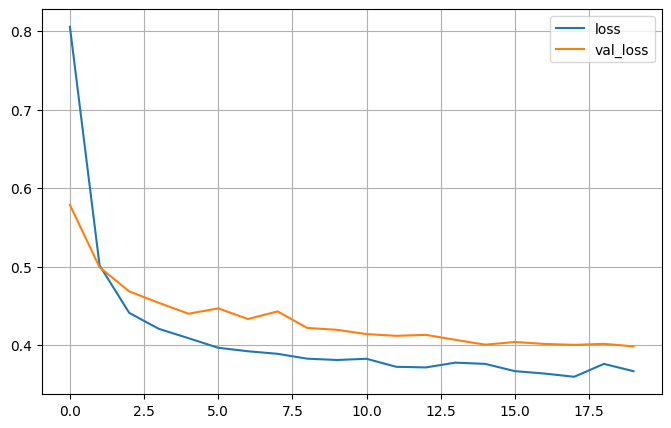

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# plot training and validating performance
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.show()

### Functions in Python

A function is a block of code which only runs when it is called. You can pass data, known as parameters, into a function. A function can return data as a result.

```
def YOUR_FUNCTION(INPUT):
    return OUTPUT
```

In [13]:
# build a basic function
def my_function():
  print("Hello from a function")

In [14]:
# call a function that is pre-defined
my_function()

Hello from a function


From above, we have seen a basic form of a python function. However, often times in practice we need to have the function execute some command based on an input. 

This input is called an argument. Let us see the following example.

In [15]:
# define
def my_function(fname):
  print("Hi, " + fname + "! Good morning!")

In [16]:
# try
my_function("Patrick")

Hi, Patrick! Good morning!


A function can take more than one arguments.

In [17]:
# define
def my_function(first_name, last_name):
    print("Morning! " + first_name + " " + last_name)

In [18]:
# run
my_function("James", "Bond")

Morning! James Bond


In machine learning, sometimes we default a parameter value in order to have the code produce some preliminary results. Let us introduce this default function.

In [19]:
# define
def my_function(a = 3):
    print("The number you entered is " + str(a) + " and the next integer is " + str(a+1))

In [20]:
# run
my_function() # this produce default input

The number you entered is 3 and the next integer is 4


In [21]:
# run
my_function(2) # the input is now defined as "2"

The number you entered is 2 and the next integer is 3


A function can return an object as you desire. To do this, we can use the *return* syntax.

In [22]:
# define
def my_function(a=3, b=2):
    return a+b**2

In [23]:
# run
my_function() # What do you think would be the default result?

7

In [24]:
# run
my_function(4,2) # What do you think the result is?

8

### Fine-Tuning Neural Network Hyperparameters

The flexibility of neural networks is also one of the main drawbacks: there are many hyperparameters to tweak. Not only can you use any imaginable network architecture, but even in a simple neural network you can change the number of layers drastically, the number of neurons per layer, the type of activation function to use in each layer, the weight initialization logic, and much more. How do we know what combination of hyperparameters is the best for your task?

One option is to try many different combinations of hyperparameters and see which one works best on the validation set (or use K-fold cross validation). 

In [25]:
# define model
def build_model(n_hidden=1, n_neurons=30, learning_rate=0.001, input_shape=[8]):
    model = tf.keras.models.Sequential()

    # What type of API are we using for input layer?
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))

    # What type of API are we using for hidden layer?
    for layer in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))

    # Why do we set number of neurons (or units) to be 1 for this following layer?
    model.add(tf.keras.layers.Dense(1))

    # A gentle reminder question: What is the difference between 
    # stochastic gradient descent and gradient descent?
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate) 

    # Another gentle reminder question: Why do we use mse or mean squared error？
    model.compile(loss="mse", optimizer=optimizer)

    return model

Recall in Week 2 we introduced linear regression. In the code walk through, we used Sci-kit Learn library to import *LinearRegression()* function and we were able to fit the data using the *.fit()* method. 

This is the code we used in Week 2. 

```
from sklearn.linear_model import LinearRegression
lm = LinearRegression() # builds up model package 
lm.fit(X_train, y_train) # trains model using training x and y
```

Now we want to design a pipeline such that the entire *Tensorflow* objects can be thrown into the Sci-kit Learn framework. This is because Sci-kit Learn library provides nice cross-validation function and we want to take advantage of that function. 

To achieve this goal, we introduce a wrapper method. The syntax is *.wrappers* under Tensorflow Keras.

In [26]:
# need to run pip install scikeras in terminal
# create a KerasRegressor based on the model defined above
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(model=build_model)


# comment:
# The KerasRegressor object is a think wrapper around the Keras model 
# built using build_model(). Since we did not specify any hyperparameters 
# when creating it, it will use the default hyperparameters we defined in 
# build_model(). This makes things convenient because we can now use 
# this object just like a regular Scikit-learn regressor. 
# In other words, we can use .fit(), .predict(), and all these concepts
# consistently as we discussed before.

In [27]:
# fit the model
keras_reg.fit(X_train, y_train, epochs=10,
              validation_data=(X_valid, y_valid),
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/10
  1/363 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - loss: 4.5592

/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6114 - val_loss: 0.9273
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8313 - val_loss: 0.8176
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7515 - val_loss: 0.7596
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6976 - val_loss: 0.7142
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6554 - val_loss: 0.6764
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6223 - val_loss: 0.6462
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5936 - val_loss: 0.6223
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5698 - val_loss: 0.6007
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5503 - val_loss: 0.5832
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5332 - val_loss: 0.5680


,model,<function bui...x794b381b04a0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [28]:
# prediction on test set
y_test_pred = keras_reg.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step


In [29]:
# mean square error on test set
import numpy as np
rmse_test = (np.sum((y_test_pred - y_test) ** 2) / len(y_test)) ** 0.5
rmse_test 

# Question: how to interpret this?

# Answer: On the test set (observations the model has not seen before)
#         the educated guess from the model make predictions with error 
#         range to be about 

np.float64(0.7207876001293378)

Note that any extra parameter you pass to the *fit()* method will get passed to the underlying Keras model. Also note that the score will be the oppositie of the MSE because Scikit-Learn wants scores, not losses (i.e. higher should be better).

We do not want to train and evaluate a single model like this, though we want to train hundreds of variants and see which one perfoms best on the validation set. Since there are many hyperparameters, it is preferable to use a randomized search.

In [30]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

In [31]:
np.arange(0, 40, 10)

array([ 0, 10, 20, 30])

In [32]:
param_distribs = {
    "model__n_hidden": [0, 1, 3],
    "model__n_neurons": np.arange(0, 40, 10)[1:],
    "optimizer__learning_rate": reciprocal(3e-4, 3e-2)
}

In [33]:
# create randomized grid search
rnd_search_cv = RandomizedSearchCV(
    keras_reg, param_distributions=param_distribs,
    n_iter=10, cv=3)

In [34]:
# fit the above randomized grid search function
rnd_search_cv.fit(X_train, y_train, epochs=10,
                  validation_data=(X_valid, y_valid),
                  callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)])

# Go get a cup of a coffee! This may take a few minutes.

Epoch 1/10
  1/242 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - loss: 4.9134

/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.8262 - val_loss: 2.5827
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8365 - val_loss: 1.4291
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1004 - val_loss: 0.9856
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8188 - val_loss: 0.8088
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7067 - val_loss: 0.7337
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6585 - val_loss: 0.6985
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6353 - val_loss: 0.6795
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6212 - val_loss: 0.6666
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6114 - val_loss: 0.6567
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6038 - val_loss: 0.6489
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
Epoch 1/10
 45/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.1762  

/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9400 - val_loss: 2.4997
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8399 - val_loss: 1.3288
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0524 - val_loss: 0.8737
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7451 - val_loss: 0.6931
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6208 - val_loss: 0.6194
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5687 - val_loss: 0.5880
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5456 - val_loss: 0.5745
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5346 - val_loss: 0.5682
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5291 - val_loss: 0.5652
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5260 - val_loss: 0.5634
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step
Epoch 1/10
 47/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.3260  

...

/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.0704 - val_loss: 3.0536
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2452 - val_loss: 1.5442
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2327 - val_loss: 0.9849
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8455 - val_loss: 0.7699
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6911 - val_loss: 0.6841
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6270 - val_loss: 0.6479
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5985 - val_loss: 0.6307
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5837 - val_loss: 0.6206
Epoch 9/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5750 - val_loss: 0.6140
Epoch 10/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5690 - val_loss: 0.6091
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step
Epoch 1/10
 46/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5780  

/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/python3.12/site-packages/scikeras/wrappers.py", line 770, in fit
    self._fit(
  File "/home/meaganb/Code/Fundamentals-of-Machine-Learning/.venv/lib/py

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.5323 - val_loss: 1.8978
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3172 - val_loss: 1.0084
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8315 - val_loss: 0.7926
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7073 - val_loss: 0.7275
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6656 - val_loss: 0.6993
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6448 - val_loss: 0.6817
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6298 - val_loss: 0.6677
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6174 - val_loss: 0.6557
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6063 - val_loss: 0.6447
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5969 - val_loss: 0.6353


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...se epochs=1 )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__n_hidden': [0, 1, ...], 'model__n_neurons': array([10, 20, 30]), 'optimizer__learning_rate': <scipy.stats....x794b3821a120>}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_mod

In [35]:
# after a long wait, we output the best parameters
rnd_search_cv.best_params_

{'model__n_hidden': 0,
 'model__n_neurons': np.int64(30),
 'optimizer__learning_rate': np.float64(0.0021222402267670713)}

In [36]:
# print the score too
rnd_search_cv.best_score_

np.float64(0.5818618573095381)

In [37]:
# extract the best model
best_model = rnd_search_cv.best_estimator_.model

In [38]:
# save the model (this is optional)
# model.save("best_model_I_just_trained.h5")

# Remark:
# This is optional, but we write this remark so you are aware
# of this procedure. In practice, the models are big and complex
# enough that sometimes there are multiple teams develop the same
# model. In this case, it is often times a safe practice to save 
# your model by using model.save("GIVE_IT_A_NAME.h5"). The format
# must be h5 format, so please only change the name of the file.
# In Colab, after you run the model.save() code successfully, you 
# will be able to see this by navigating to "Content" using the left 
# menu bar. Go to the "folder" button and choose "Content".

Investigation ends here.